In [16]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


from src.models.logistic_regression import LogisticRegression
from src.optimizers.gradient_descent import GradientDescent
from src.optimizers.newton_raphson import NewtonRaphson

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Dataset generado:
- Muestras totales: 200
- Estudiantes Reprobados (0): 49
- Estudiantes Aprobados (1): 151


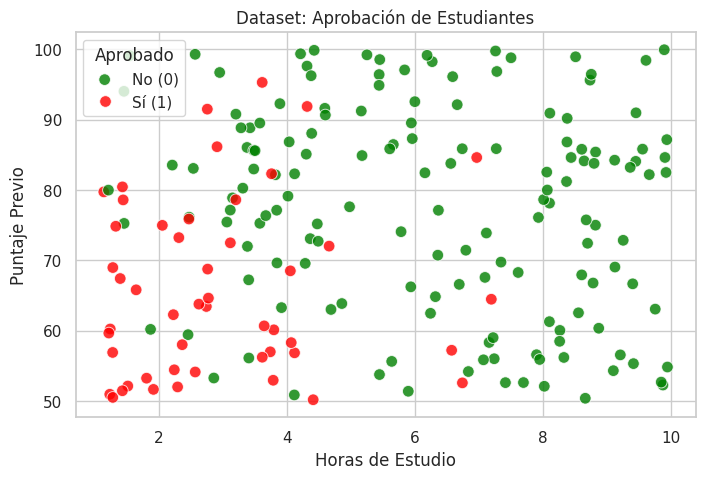

In [25]:
np.random.seed(30)
n_samples = 200

hours_studied = np.random.uniform(1, 10, n_samples)
previous_score = np.random.uniform(50, 100, n_samples)

logits = -8 + 0.8 * hours_studied + 0.08 * previous_score
true_probs = 1 / (1 + np.exp(-logits))
y = (np.random.binomial(1, true_probs)).astype(int)

X = np.column_stack((hours_studied, previous_score))

print(f"Dataset generado:")
print(f"- Muestras totales: {X.shape[0]}")
print(f"- Estudiantes Reprobados (0): {np.sum(y == 0)}")
print(f"- Estudiantes Aprobados (1): {np.sum(y == 1)}")

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette={0: "red", 1: "green"},
    alpha=0.8,
    s=70,
)
plt.title("Dataset: Aprobación de Estudiantes")
plt.xlabel("Horas de Estudio")
plt.ylabel("Puntaje Previo")
plt.legend(title="Aprobado", labels=["No (0)", "Sí (1)"])
plt.show()

In [26]:
gd_optimizer = GradientDescent(learning_rate=0.01, max_iter=2000, tol=1e-6)
model_gd = LogisticRegression(optimizer=gd_optimizer)
model_gd.fit(X, y)

nr_optimizer = NewtonRaphson(max_iter=50, tol=1e-6)
model_nr = LogisticRegression(optimizer=nr_optimizer)
model_nr.fit(X, y)

print("=== RESULTADOS DEL ENTRENAMIENTO ===")
print(f"Descenso del Gradiente -> Iteraciones: {len(gd_optimizer.history)}")
print(f"  - Intercepto (b): {model_gd.intercept_:.4f}")
print(f"  - Coeficientes (w): {model_gd.coef_}")

print(f"\nNewton-Raphson        -> Iteraciones: {len(nr_optimizer.history)}")
print(f"  - Intercepto (b): {model_nr.intercept_:.4f}")
print(f"  - Coeficientes (w): {model_nr.coef_}")

=== RESULTADOS DEL ENTRENAMIENTO ===
Descenso del Gradiente -> Iteraciones: 2000
  - Intercepto (b): -0.7088
  - Coeficientes (w): [ 2.02165767 -0.02246443]

Newton-Raphson        -> Iteraciones: 7
  - Intercepto (b): -8.0092
  - Coeficientes (w): [0.80380928 0.07837314]


In [27]:
gd_optimizer = GradientDescent(learning_rate=0.01, max_iter=2000, tol=1e-6)
model_gd = LogisticRegression(optimizer=gd_optimizer)
model_gd.fit(X, y)

nr_optimizer = NewtonRaphson(max_iter=50, tol=1e-6)
model_nr = LogisticRegression(optimizer=nr_optimizer)
model_nr.fit(X, y)

print("=== RESULTADOS DEL ENTRENAMIENTO ===")
print(f"Descenso del Gradiente -> Iteraciones: {len(gd_optimizer.history)}")
print(f"  - Intercepto (b): {model_gd.intercept_:.4f}")
print(f"  - Coeficientes (w): {model_gd.coef_}")

print(f"\nNewton-Raphson        -> Iteraciones: {len(nr_optimizer.history)}")
print(f"  - Intercepto (b): {model_nr.intercept_:.4f}")
print(f"  - Coeficientes (w): {model_nr.coef_}")

=== RESULTADOS DEL ENTRENAMIENTO ===
Descenso del Gradiente -> Iteraciones: 2000
  - Intercepto (b): -0.7088
  - Coeficientes (w): [ 2.02165767 -0.02246443]

Newton-Raphson        -> Iteraciones: 7
  - Intercepto (b): -8.0092
  - Coeficientes (w): [0.80380928 0.07837314]


In [28]:
from sklearn.linear_model import LogisticRegression as SklearnLogistic
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
# 1. Gradient Descent
start_time = time.time()
gd_opt = GradientDescent(learning_rate=0.01, max_iter=2000, tol=1e-6)
pystat_gd = LogisticRegression(optimizer=gd_opt)
pystat_gd.fit(X, y)
time_pystat_gd = time.time() - start_time

preds_gd = pystat_gd.predict(X)
probs_gd = pystat_gd.predict_proba(X)

# 2. Newton-Raphson
start_time = time.time()
nr_opt = NewtonRaphson(max_iter=50, tol=1e-6)
pystat_nr = LogisticRegression(optimizer=nr_opt)
pystat_nr.fit(X, y)
time_pystat_nr = time.time() - start_time

preds_nr = pystat_nr.predict(X)
probs_nr = pystat_nr.predict_proba(X)

# 3. Scikit-Learn (L-BFGS)
start_time = time.time()
sklearn_model = SklearnLogistic(C=np.inf, solver="lbfgs", max_iter=1000)
sklearn_model.fit(X, y)
time_sklearn = time.time() - start_time

preds_sk = sklearn_model.predict(X)
probs_sk = sklearn_model.predict_proba(X)[:, 1]

results = pd.DataFrame(
    {
        "Modelo / Optimizador": [
            "PyStat (Gradient Descent)",
            "PyStat (Newton-Raphson)",
            "Scikit-Learn (L-BFGS)",
        ],
        "Iteraciones": [
            len(gd_opt.history),
            len(nr_opt.history),
            sklearn_model.n_iter_[0],
        ],
        "Tiempo (s)": [
            f"{time_pystat_gd:.4f}",
            f"{time_pystat_nr:.4f}",
            f"{time_sklearn:.4f}",
        ],
        "Accuracy": [
            accuracy_score(y, preds_gd),
            accuracy_score(y, preds_nr),
            accuracy_score(y, preds_sk),
        ],
        "Log-Loss": [
            log_loss(y, probs_gd),
            log_loss(y, probs_nr),
            log_loss(y, probs_sk),
        ],
        "Intercepto ($b$)": [
            f"{pystat_gd.intercept_:.4f}",
            f"{pystat_nr.intercept_:.4f}",
            f"{sklearn_model.intercept_[0]:.4f}",
        ],
        "Coef ($w_1, w_2$)": [
            np.round(pystat_gd.coef_, 4),
            np.round(pystat_nr.coef_, 4),
            np.round(sklearn_model.coef_[0], 4),
        ],
    }
)

display(results)

,Modelo / Optimizador,Iteraciones,Tiempo (s),Accuracy,Log-Loss,Intercepto ($b$),"Coef ($w_1, w_2$)"
0,PyStat (Gradient Descent),2000,0.1169,0.755,0.966482,-0.7088,"[2.0217, -0.0225]"
1,PyStat (Newton-Raphson),7,0.0017,0.890,0.312811,-8.0092,"[0.8038, 0.0784]"
2,Scikit-Learn (L-BFGS),32,0.0599,0.890,0.312811,-8.0093,"[0.8038, 0.0784]"


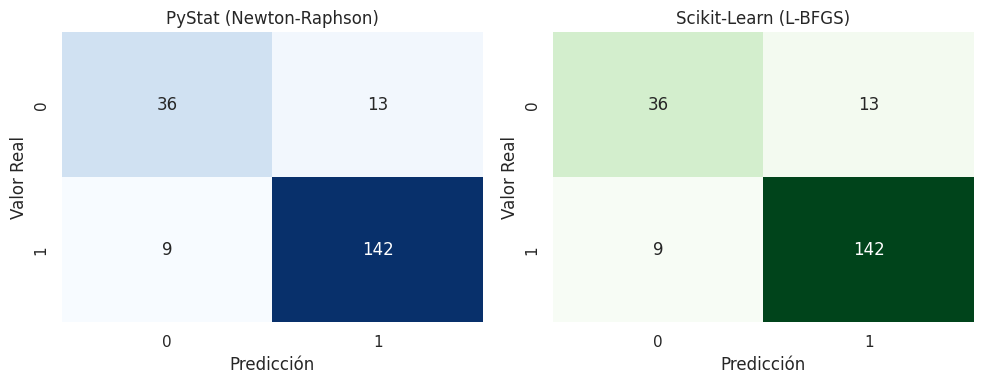

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_nr = confusion_matrix(y, preds_nr)
sns.heatmap(cm_nr, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("PyStat (Newton-Raphson)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor Real")

cm_sk = confusion_matrix(y, preds_sk)
sns.heatmap(cm_sk, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title("Scikit-Learn (L-BFGS)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

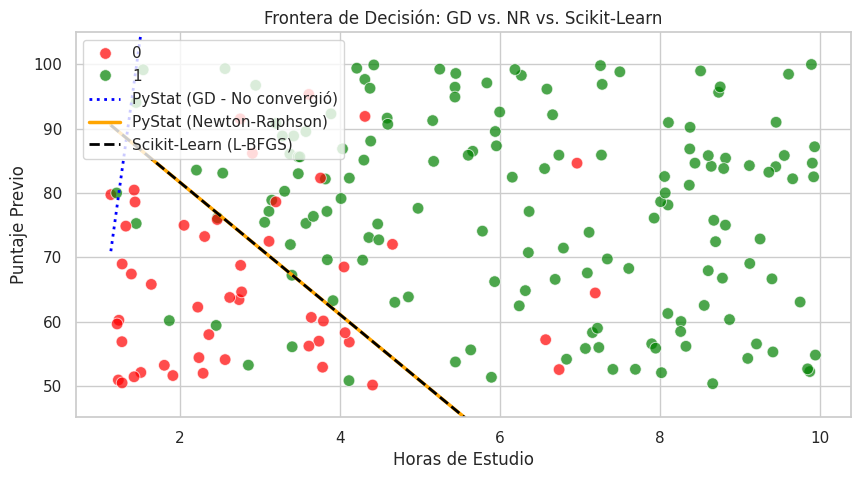

In [30]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette={0: "red", 1: "green"},
    s=70,
    alpha=0.7,
)

x1_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

x2_gd = -(pystat_gd.intercept_ + pystat_gd.coef_[0] * x1_vals) / pystat_gd.coef_[1]
plt.plot(x1_vals, x2_gd, label="PyStat (GD - No convergió)", color="blue", linestyle=":", linewidth=2)

x2_nr = -(pystat_nr.intercept_ + pystat_nr.coef_[0] * x1_vals) / pystat_nr.coef_[1]
plt.plot(x1_vals, x2_nr, label="PyStat (Newton-Raphson)", color="orange", linewidth=2.5)

x2_sk = -(sklearn_model.intercept_[0] + sklearn_model.coef_[0][0] * x1_vals) / sklearn_model.coef_[0][1]
plt.plot(x1_vals, x2_sk, label="Scikit-Learn (L-BFGS)", color="black", linestyle="--", linewidth=2)

plt.title("Frontera de Decisión: GD vs. NR vs. Scikit-Learn")
plt.xlabel("Horas de Estudio")
plt.ylabel("Puntaje Previo")
plt.legend(loc="upper left")
plt.ylim(X[:, 1].min() - 5, X[:, 1].max() + 5)
plt.show()

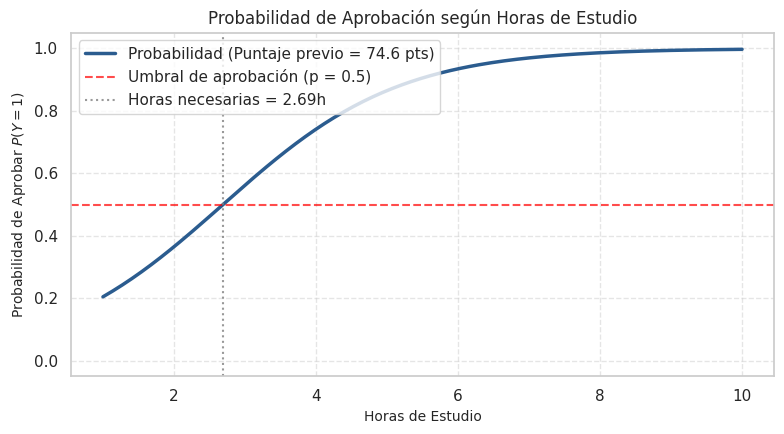

In [31]:
mean_score = np.mean(X[:, 1])
hours_range = np.linspace(1, 10, 200)

b = pystat_nr.intercept_
w1, w2 = pystat_nr.coef_

z = b + w1 * hours_range + w2 * mean_score
probabilities = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4.5))
plt.plot(hours_range, probabilities, color="#2b5c8f", linewidth=2.5, label=f"Probabilidad (Puntaje previo = {mean_score:.1f} pts)")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="Umbral de aprobación (p = 0.5)")

hours_needed = (0 - b - w2 * mean_score) / w1
if 1 <= hours_needed <= 10:
    plt.axvline(hours_needed, color="gray", linestyle=":", alpha=0.8, label=f"Horas necesarias = {hours_needed:.2f}h")

plt.title("Probabilidad de Aprobación según Horas de Estudio", fontsize=12)
plt.xlabel("Horas de Estudio", fontsize=10)
plt.ylabel("Probabilidad de Aprobar $P(Y=1)$", fontsize=10)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig("sigmoid_estudiantes.png", dpi=300)
plt.show()